# The WaveVI Interface

$_{Yongtao}$ $_{Liu,}$ $_{liuy3@ornl.gov,}$ $_{youngtaoliu@gmail.com}$

$_{July}$ $_{2026}$

## Overview

`PyWaveVI` is the AEcroscopy interface for the **LabVIEW-based DAQ control application** (PyScanner, running as `PyScanner_FPGA_6124_01.exe`). It manages communication with the NI-6124 DAQ card to upload and execute voltage waveforms for AFM experiments.

The typical workflow is:
1. Initialize a `PyWaveVI` instance pointing to the PyScanner executable.
2. Configure I/O settings (amplifier, channels, timeout).
3. Generate a waveform with `WaveGenerator` and upload it via `set_AO_waveforms()`.
4. Execute the waveform with `set_IO_control()` or the lower-level `upload_to_6124()` / `run_6124_IO_10()`.

## Import

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from aecroscopywave.interfaces import WaveVI
from aecroscopywave.wavebuilding import WaveGenerator

## Initialize PyWaveVI

Provide the path to the PyScanner executable. `PyWaveVI` launches the application and establishes a COM connection. Ensure the path matches your local installation.

In [ ]:
_path = r'C:\Users\PyScanner_FPGA_6124_01\PyScanner_FPGA_6124_01.exe'
pyvi = WaveVI.PyWaveVI(vi_path = _path)

## Get I/O Settings

Returns the current I/O setting indices (integer codes). These correspond to hardware configuration options like amplifier selection and channel enable flags, not the physical values.

In [ ]:
pyvi.get_IO_settings()

{'trigger_type': 0,
 'AO_num_channels': 0.0,
 'IO_rate': 0.0,
 'AI_range': 0.0,
 'AO_range': 0.0,
 'AO_amplifier': 0.0,
 'IO_trigger_ring': 0,
 'IO_timeout': 20.0,
 'AI_ch01': False,
 'AI_ch02': False,
 'AI_ch03': False}

## Get I/O Parameters

Returns the actual physical I/O parameters (e.g., sample rate, voltage ranges) based on the current settings. Use this to verify the hardware configuration before running an experiment.

In [ ]:
pyvi.get_IO_parameters()

{'IO_rate_b': 0,
 'IO_AO_range_b': 0.0,
 'IO_AO_routing_b': 0.0,
 'AO_amp_b': 0.0,
 'IO_AI_range_b': 0.0,
 'AI Actual Rate': 4000000.0,
 'AO Actual Rate': 4000000.0,
 'samples per channel': 0}

## Change I/O Settings

Update I/O settings by passing a dictionary of setting keys and values. Common keys: `AO_amplifier` (output amplifier index), `IO_timeout` (seconds), `AI_ch01/02/03` (enable input channels).

In [ ]:
pyvi.set_IO_settings(IO_setting_dict ={"AO_amplifier": 1, "IO_timeout": 5, "AI_ch01": 1, "AI_ch02": 1, "AI_ch03": 1})

## Set Band Excitation Wave

Generate a Band Excitation waveform with `WaveGenerator.be_wave()` and upload it to the LabVIEW interface. The BE wave spans a frequency band around a center frequency for multi-frequency piezoresponse imaging.

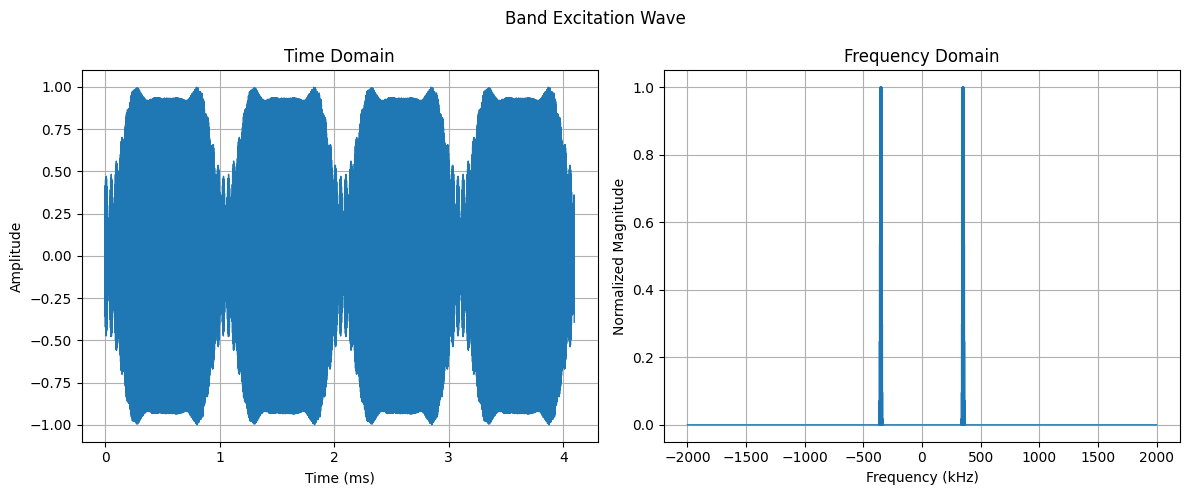

In [ ]:
# Set basic BE excitation wave using function from PyWaveGenerator
BE_wave, FFT_BE, w_vec, BE_hot_bin_ind  = WaveGenerator.be_wave(BE_band_center = 350E3, BE_band_width = 30E3, BE_amplitude = 1.0, 
                                                                  BE_repeats = int(2), BE_pulse_duration_req = 4.0E-3, BE_phase_variation=1)

# Plot the BE wave
WaveGenerator.plot_BE_wave(BE_wave, FFT_BE, w_vec, IO_rate=4e6,title="Band Excitation Wave")

## Upload Waveform to LabVIEW

`set_AO_waveforms()` uploads the waveform to the LabVIEW VI buffer. Set `zero_tail=True` to append a zero-voltage tail after the waveform, ensuring the output returns to 0 V at the end.

In [ ]:
pyvi.set_AO_waveforms(waveform = BE_wave, zero_tail= False)

Waveform duration: 0.004096 s


## Get Current Output Waveform

Reads back the waveform currently loaded in the LabVIEW VI buffer. Note: this reflects what is in the VI, which may differ from what has been sent to the NI-6124 card.

Waveform duration: 0.004096 s


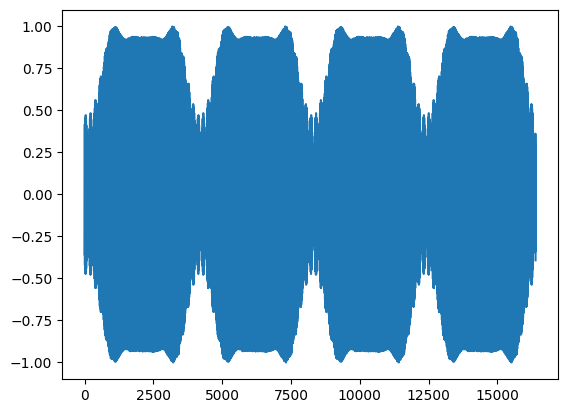

In [ ]:
current_waveform = pyvi.get_AO_waveforms()
plt.plot(current_waveform)

## Get Acquired Input Waveform

Reads the acquired analog input (AI) data from the LabVIEW interface after an experiment has run. This contains the raw measured signal (e.g., cantilever deflection, lock-in output).

In [ ]:
pyvi.get_AI_waveforms()

array([], dtype=float64)

## Clear NI-6124 Device

Resets the NI-6124 DAQ card buffer. This is typically required before uploading a new waveform to ensure no stale data remains.

In [ ]:
pyvi.clear_6124()

## Upload Waveform to NI-6124

Transfers the waveform from the LabVIEW VI buffer to the NI-6124 card memory, making it ready for hardware execution.

In [ ]:
pyvi.upload_to_6124()

## Execute Waveform

`run_6124_IO_10()` triggers the NI-6124 card to output the uploaded waveform and simultaneously acquire the input signals.

`set_IO_control()` is a higher-level convenience method that combines clear, upload, and execute steps into a single call with flags: `clear`, `upload`, `do_IO`, and `fetch_result`.

In [ ]:
pyvi.run_6124_IO_10()

In [ ]:
pyvi.set_IO_control()

array([], dtype=float64)